In [ ]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define the project root (one folder up from /workshop)
project_root = Path("..").resolve()

# Add the project root to sys.path so Jupyter can find your 'src' module
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Load data/valencia_cf_1/matches.json into a dataframe called matches_df
matches_path = project_root / "tests" / "fixtures" / "full_example_data" / "data" / "valencia_cf_1" / "matches.json"
matches_df = pd.read_json(matches_path)
matches_df.head()

,id,datetime,data,player_performances
0,1,2026-02-02 15:13:40,"{'in_game_date': '2029-08-15T00:00:00', 'compe...","[{'performance_type': 'GK', 'shots_against': 1..."
1,2,2026-02-02 22:14:58,"{'in_game_date': '2029-08-18T00:00:00', 'compe...","[{'performance_type': 'Outfield', 'positions_p..."
2,3,2026-02-02 23:35:30,"{'in_game_date': '2029-08-25T00:00:00', 'compe...","[{'performance_type': 'Outfield', 'positions_p..."
3,4,2026-02-03 14:17:17,"{'in_game_date': '2029-08-29T00:00:00', 'compe...","[{'performance_type': 'Outfield', 'positions_p..."
4,5,2026-02-04 00:55:47,"{'in_game_date': '2029-09-02T00:00:00', 'compe...","[{'performance_type': 'Outfield', 'positions_p..."


In [89]:
match_ratings_match_ids_list = []
for index, row in matches_df.iterrows():
    match_id = row["id"]
    player_performances = row["player_performances"]
    for performance in player_performances:
        match_rating = performance.get("match_rating")
        if match_rating is not None:
            match_ratings_match_ids_list.append({"match_rating": match_rating, "match_id": match_id})

match_ratings_match_ids_df = pd.DataFrame(match_ratings_match_ids_list)
# Print the lowest and highest match ratings
print(f"Lowest match rating: {match_ratings_match_ids_df['match_rating'].min()}")
print(f"Highest match rating: {match_ratings_match_ids_df['match_rating'].max()}")

Lowest match rating: 4.4
Highest match rating: 10.0


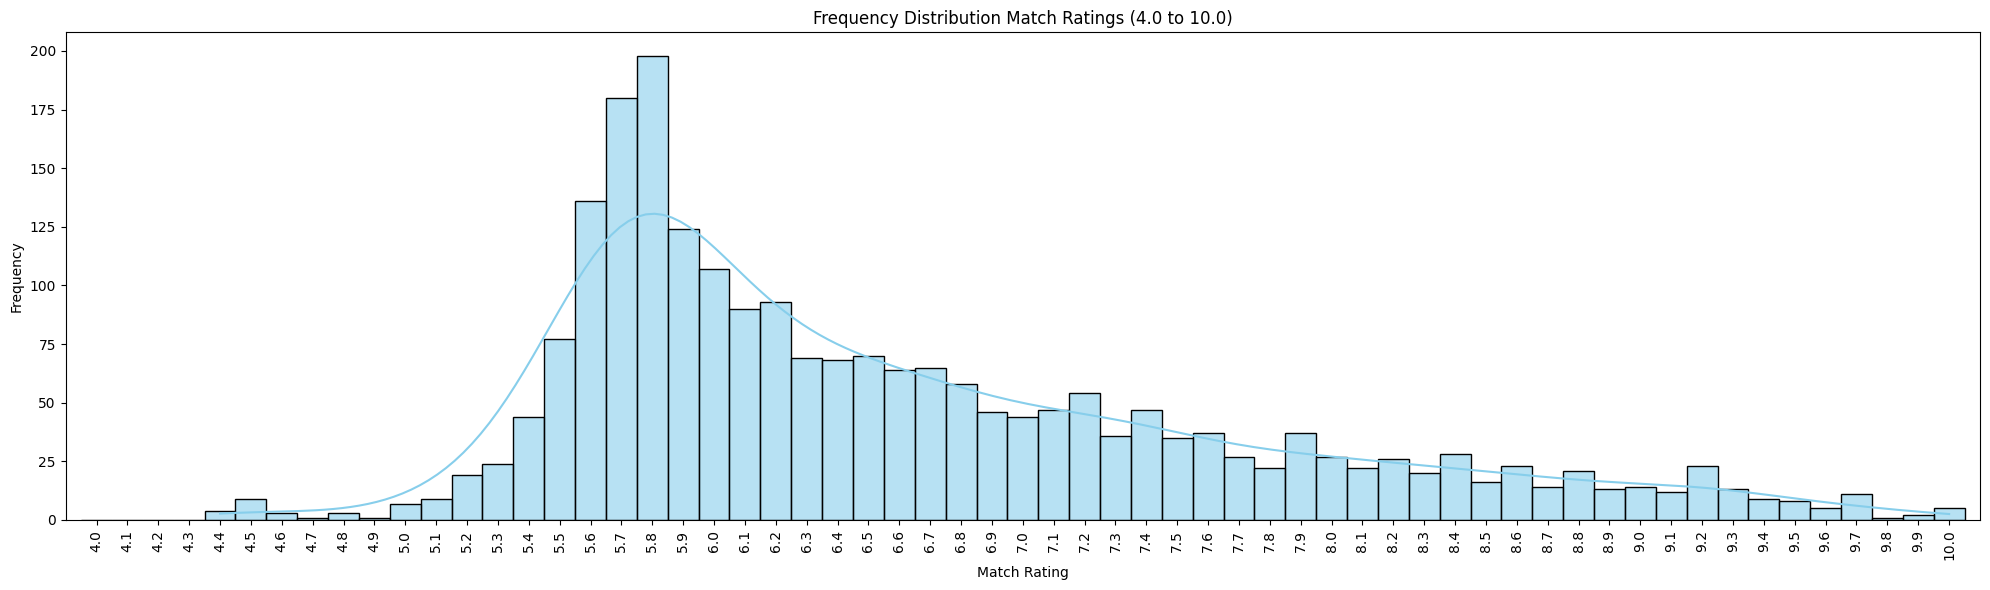

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Replace this with your actual list of 1dp floats
data = match_ratings_match_ids_df['match_rating'].tolist()

# 1. Create a wide figure to accommodate all 61 ticks without crowding
plt.figure(figsize=(20, 6))

# 2. Offset the bin edges so the bars center exactly on your 1dp values
# E.g., the bin for 4.0 will span from 3.95 to 4.05
bins = np.arange(3.95, 10.15, 0.1)

# Plot histogram with KDE (Kernel Density Estimate) to show the smooth curve
sns.histplot(data, bins=bins, kde=True, color="skyblue", edgecolor="black", alpha=0.6)

# 3. Explicitly set the x-ticks to every 0.1 between 4.0 and 10.0
xticks = np.round(np.arange(4.0, 10.1, 0.1), 1)
plt.xticks(xticks, rotation=90) # Rotate 90 degrees for readability

# Restrict the plot limits to clip off empty space
plt.xlim(3.9, 10.1)

# Add Labels
plt.title("Frequency Distribution Match Ratings (4.0 to 10.0)")
plt.xlabel("Match Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [91]:
match_ratings_minutes_list = []
for index, row in matches_df.iterrows():
    match_id = row["id"]
    player_performances = row["player_performances"]
    for performance in player_performances:
        match_rating = performance.get("match_rating")
        minutes_played = performance.get("minutes_played")
        if match_rating is not None and minutes_played is not None:
            match_ratings_minutes_list.append({"match_rating": match_rating, "minutes_played": minutes_played})

match_ratings_minutes_df = pd.DataFrame(match_ratings_minutes_list)

match_ratings = match_ratings_minutes_df['match_rating'].tolist()
minutes_played = match_ratings_minutes_df['minutes_played'].tolist()

In [92]:
def bland_altman_plot(data1, data2, *args, **kwargs):
    data1     = np.asarray(data1)
    data2     = np.asarray(data2)
    mean      = np.mean([data1, data2], axis=0)
    diff      = data1 - data2                   # Difference between data1 and data2
    md        = np.mean(diff)                   # Mean of the difference
    sd        = np.std(diff, axis=0)            # Standard deviation of the difference

    plt.scatter(mean, diff, *args, **kwargs)
    plt.axhline(md,           color='gray', linestyle='--')
    plt.axhline(md + 1.96*sd, color='gray', linestyle='--', c='orange', label=r'+ 1.96$\sigma$')
    plt.axhline(md - 1.96*sd, color='gray', linestyle='--', c='magenta', label=r'- 1.96$\sigma$')
    plt.legend()
    plt.xlabel("Average")
    plt.ylabel("Difference")

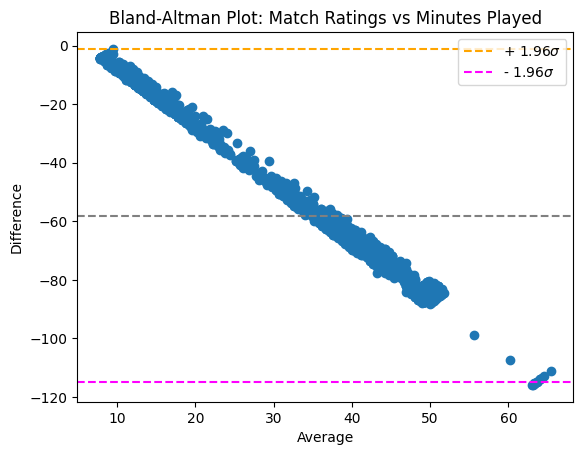

In [94]:
bland_altman_plot(match_ratings, minutes_played)
plt.title("Bland-Altman Plot: Match Ratings vs Minutes Played")
plt.show()